Transforms
==========

Data does not always come in its final processed form that is required
for training machine learning algorithms. We use **transforms** to
perform some manipulation of the data and make it suitable for training.

All TorchVision datasets have two parameters -`transform` to modify the
features and `target_transform` to modify the labels - that accept
callables containing the transformation logic. The
[torchvision.transforms](https://pytorch.org/vision/stable/transforms.html)
module offers several commonly-used transforms out of the box.

The FashionMNIST features are in PIL Image format, and the labels are
integers. For training, we need the features as normalized tensors, and
the labels as one-hot encoded tensors. To make these transformations, we
use the `torchvision.transforms.v2` API along with
`torch.nn.functional.one_hot`.


In [1]:
import torch
import torch.nn.functional as F
from torchvision import datasets
from torchvision.transforms import v2

ds = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)]),
    target_transform=v2.Lambda(
        lambda y: F.one_hot(torch.tensor(y), num_classes=10).float()
    ),
)

ToImage() and ToDtype()
=======================

The `torchvision.transforms.v2` API replaces the legacy `ToTensor`
transform with a two-step pipeline.
[v2.ToImage](https://pytorch.org/vision/stable/generated/torchvision.transforms.v2.ToImage.html)
converts a PIL image or NumPy `ndarray` into a
`torchvision.tv_tensors.Image` tensor, and
[v2.ToDtype](https://pytorch.org/vision/stable/generated/torchvision.transforms.v2.ToDtype.html)
with `scale=True` casts it to `float32` and scales the pixel intensity
values to the range \[0., 1.\].


Lambda Transforms
=================

Lambda transforms apply any user-defined lambda function. Here, we use
[torch.nn.functional.one\_hot](https://pytorch.org/docs/stable/generated/torch.nn.functional.one_hot.html)
to turn the integer label into a one-hot encoded tensor of size 10 (the
number of labels in our dataset), then cast it to `float` to match the
expected dtype.


In [2]:
target_transform = v2.Lambda(
    lambda y: F.one_hot(torch.tensor(y), num_classes=10).float()
)

## Visualizing the effect of transforms

Let's actually look at what these transforms do to an image, rather than just reading about them. We'll load the raw PIL image (no transform) alongside the `ToImage`/`ToDtype` tensor version, and inspect the one-hot label.

Raw label: 9 (Ankle Boot)
One-hot label: tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])
Tensor image shape: torch.Size([1, 28, 28]), dtype: torch.float32, min/max: 0.000/1.000


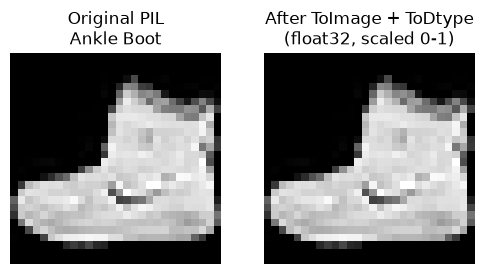

In [3]:
import matplotlib.pyplot as plt

labels_map = {
    0: "T-Shirt", 1: "Trouser", 2: "Pullover", 3: "Dress", 4: "Coat",
    5: "Sandal", 6: "Shirt", 7: "Sneaker", 8: "Bag", 9: "Ankle Boot",
}

# Raw dataset with NO transform, so we get the original PIL image + int label
raw_ds = datasets.FashionMNIST(root="data", train=True, download=True)

pil_img, raw_label = raw_ds[0]
tensor_img, onehot_label = ds[0]

print(f"Raw label: {raw_label} ({labels_map[raw_label]})")
print(f"One-hot label: {onehot_label}")
print(f"Tensor image shape: {tensor_img.shape}, dtype: {tensor_img.dtype}, "
      f"min/max: {tensor_img.min():.3f}/{tensor_img.max():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(pil_img, cmap="gray")
axes[0].set_title(f"Original PIL\n{labels_map[raw_label]}")
axes[0].axis("off")

axes[1].imshow(tensor_img.squeeze(), cmap="gray")
axes[1].set_title("After ToImage + ToDtype\n(float32, scaled 0-1)")
axes[1].axis("off")
plt.show()

## Other common `v2` transforms

Beyond `ToImage`/`ToDtype`/`Lambda`, `torchvision.transforms.v2` offers many more building blocks, commonly composed with `v2.Compose`. Let's try a few and see their visual effect on the same image:

- **`v2.Normalize`** — shifts/scales pixel values using a per-channel mean and std (`(x - mean) / std`). Common for feeding pretrained models; here we just show the raw numeric effect since FashionMNIST is single-channel.
- **`v2.RandomHorizontalFlip`** — flips the image left-right with some probability.
- **`v2.RandomRotation`** — rotates the image by a random angle within a range.
- **`v2.RandomCrop`** with padding — pads then crops a random region, a common augmentation for shift-invariance.
- **`v2.ColorJitter`** — randomly perturbs brightness/contrast (mostly useful for RGB, but works here too).

In [ ]:
base = v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
base_img = base(pil_img)  # shape (1, 28, 28), values in [0, 1]

transforms_to_try = {
    "Original": v2.Identity(),
    "Normalize\n(mean=0.5, std=0.5)": v2.Normalize(mean=[0.5], std=[0.5]),
    "RandomHorizontalFlip\n(p=1.0)": v2.RandomHorizontalFlip(p=1.0),
    "RandomRotation\n(±30°)": v2.RandomRotation(degrees=30),
    "RandomCrop\n(pad=4, size=28)": v2.RandomCrop(28, padding=4),
    "ColorJitter\n(brightness/contrast)": v2.ColorJitter(brightness=0.5, contrast=0.5),
}

fig, axes = plt.subplots(1, len(transforms_to_try), figsize=(15, 3))
for ax, (name, t) in zip(axes, transforms_to_try.items()):
    out = t(base_img)
    ax.imshow(out.squeeze(), cmap="gray")
    ax.set_title(name, fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

### Augmentation preview grid

A common pattern before training: apply a *random* augmentation pipeline to the same image several times, to sanity-check what the model will actually see during training (since random transforms produce a different result each call).

In [ ]:
augment = v2.Compose([
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomRotation(degrees=15),
    v2.RandomCrop(28, padding=2),
])

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for ax in axes.flat:
    augmented = augment(base_img)
    ax.imshow(augmented.squeeze(), cmap="gray")
    ax.axis("off")
fig.suptitle(f"8 random augmentations of the same '{labels_map[raw_label]}' image")
plt.tight_layout()
plt.show()

## Summary

This notebook covers `torchvision.transforms.v2`:

1. **`ToImage` + `ToDtype`** — converts a PIL image / NumPy array to a tensor and casts it to `float32` scaled into `[0, 1]`, replacing the legacy `ToTensor`.
2. **`Lambda` transforms** — wrap any callable (here, `F.one_hot`) to transform labels, e.g. turning an integer class into a one-hot float tensor.
3. **Visualizing transforms** — compared the raw PIL image against its tensor form, and inspected shape/dtype/value range to confirm what the pipeline actually produces.
4. **Other `v2` building blocks** — `Normalize` (mean/std standardization), `RandomHorizontalFlip`, `RandomRotation`, `RandomCrop` (with padding), and `ColorJitter`, each shown side-by-side on the same image.
5. **Augmentation preview grid** — composed a random-augmentation pipeline (`Flip` + `Rotation` + `Crop`) and sampled it 8 times on one image to see the variety a model would encounter during training.
